/tmp/ipykernel_416/3517168487.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc=yf.download("BTC-USD",period="5y")
[*********************100%***********************]  1 of 1 completed


Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2021-03-08  52246.523438  52314.070312  49506.054688  51174.117188   
2021-03-09  54824.117188  54824.117188  51981.832031  52272.968750   
2021-03-10  56008.550781  57258.253906  53290.890625  54824.011719   
2021-03-11  57805.121094  58091.062500  54484.593750  55963.179688   
2021-03-12  57332.089844  57996.621094  55376.648438  57821.218750   
...                  ...           ...           ...           ...   
2026-03-04  72710.578125  74051.804688  67437.406250  68290.562500   
2026-03-05  70841.125000  73555.789062  70654.882812  72712.656250   
2026-03-06  68136.492188  71378.570312  67757.820312  70842.156250   
2026-03-07  67272.593750  68515.164062  66969.257812  68136.687500   
2026-03-08  66903.820312  68085.101562  66625.468750  67250.101562   

Price            Vo

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


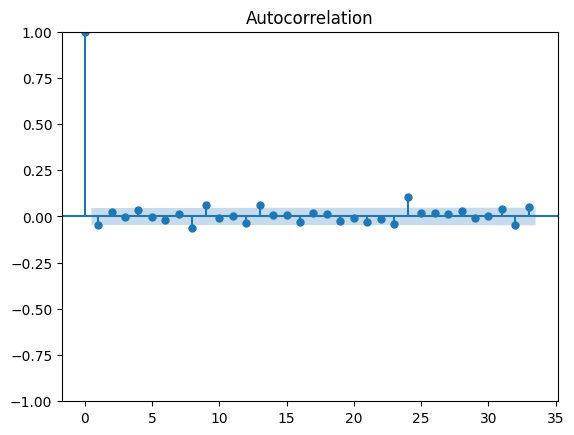

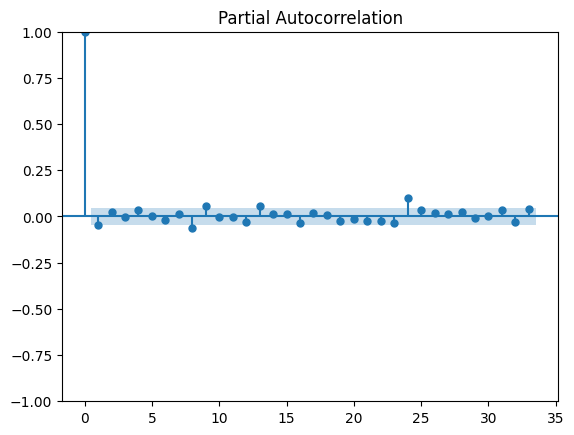

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

btc=yf.download("BTC-USD",period="5y")
prices=btc["Close"]
print(btc)
log_returns =np.log(prices/prices.shift(1)).dropna()
result=adfuller(log_returns)
print(result[1])
plot_acf(log_returns)
plot_pacf(log_returns)
model_ar1=AutoReg(log_returns,lags=1).fit()
print(model_ar1.summary())
aic_ar1=model_ar1.aic
print(aic_ar1)
model_ar2=AutoReg(log_returns,lags=2).fit()
print(model_ar1.summary())
aic_ar2=model_ar2.aic
print("AR(1)AIC:",aic_ar1)
print("AR(2)AIC:",aic_ar2)
forecast=model_ar1.forecast(5)
print(forecast)

In [ ]:
forecast=model_ar1.forecast(5)
print(forecast)

2026-03-09    0.000259
2026-03-10    0.000105
2026-03-11    0.000112
2026-03-12    0.000112
2026-03-13    0.000112
Freq: D, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
#ARIMA
diff_series = prices.diff().dropna()
adf_diff = adfuller(diff_series)
print(adf_diff[1])
model_arima = ARIMA(prices, order=(1,1,1)).fit()
print(model_arima.summary())
aic_value = model_arima.aic
print("ARIMA AIC:", aic_value)
forecast = model_arima.forecast(5)
print(forecast)

2.2977545871788142e-12
                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 1827
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -16103.964
Date:                Sun, 08 Mar 2026   AIC                          32213.929
Time:                        18:26:33   BIC                          32230.458
Sample:                    03-08-2021   HQIC                         32220.026
                         - 03-08-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0093      0.669      0.014      0.989      -1.301       1.320
ma.L1         -0.0358      0.667     -0.054      0.957      -1.344       1.272
sigma2      2.672e+06   5.01e

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2026-03-09    66914.488683
2026-03-10    66914.587857
2026-03-11    66914.588779
2026-03-12    66914.588787
2026-03-13    66914.588788
Freq: D, Name: predicted_mean, dtype: float64
